In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# IMPORT LIBRARIES AND PROJECT PATHS

import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

import joblib

In [3]:
# Reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


# Project folders

BASE_DIR = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"
CONFIG_DIR = BASE_DIR / "config"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)
REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)
CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", DATA_DIR.exists())

BASE_DIR: /content/drive/MyDrive/intentmap-nids/intentmap-nids
DATA_DIR: /content/drive/MyDrive/intentmap-nids/intentmap-nids/data/processed
DATA_DIR exists: True


In [4]:
#  CHECK PROCESSED DATA FILES

print("Processed files:")

for file in sorted(DATA_DIR.iterdir()):
    print("-", file.name)

Processed files:
- config
- models
- reports
- test_dedup.npz
- test_full.npz
- train_normal.npz
- val_normal.npz


In [5]:
# LOAD TRAIN / VALIDATION / TEST DATA

def load_npz(path):
    data = np.load(path)
    X = data["X"]
    y = data["y"] if "y" in data.files else None
    return X, y


X_train, _ = load_npz(DATA_DIR / "train_normal.npz")
X_val, _ = load_npz(DATA_DIR / "val_normal.npz")
X_test, y_test = load_npz(DATA_DIR / "test_full.npz")

print("Normal training data:", X_train.shape)
print("Normal validation data:", X_val.shape)
print("Full testing data:", X_test.shape)

if y_test is not None:
    print("Normal test records:", (y_test == 0).sum())
    print("Attack test records:", (y_test == 1).sum())

Normal training data: (41065, 41)
Normal validation data: (10266, 41)
Full testing data: (82332, 41)
Normal test records: 37000
Attack test records: 45332


In [6]:
# DATA QUALITY CHECK

print("Training minimum:", np.min(X_train))
print("Training maximum:", np.max(X_train))
print("Training mean:", np.mean(X_train))
print("Training std:", np.std(X_train))

print("\nAny NaN:", np.isnan(X_train).any())
print("Any infinity:", np.isinf(X_train).any())


Training minimum: -3.388441571325508
Training maximum: 7.981187493058512
Training mean: 0.08408545533419882
Training std: 0.5488583224901848

Any NaN: False
Any infinity: False


In [7]:
# BUILD LOF BASELINE MODEL

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    metric="minkowski",
    p=2,
    contamination="auto",
    novelty=True,
    n_jobs=-1
)

print("LOF model created.")
print(lof_model)

LOF model created.
LocalOutlierFactor(n_jobs=-1, novelty=True)


In [8]:
# TRAIN LOF ON NORMAL DATA ONLY

lof_model.fit(X_train)

print("LOF training completed.")
print("Training records:", X_train.shape[0])
print("Input features:", X_train.shape[1])

LOF training completed.
Training records: 41065
Input features: 41


In [9]:
# CREATE LOF ANOMALY SCORES

def lof_anomaly_scores(model, X):
    normality_scores = model.score_samples(X)
    return -normality_scores


train_scores = lof_anomaly_scores(lof_model, X_train)
val_scores = lof_anomaly_scores(lof_model, X_val)
test_scores = lof_anomaly_scores(lof_model, X_test)

print("Training LOF scores:")
print("Mean:", train_scores.mean(), "Std:", train_scores.std())

print("\nValidation LOF scores:")
print("Mean:", val_scores.mean(), "Std:", val_scores.std())

print("\nTest LOF scores:")
print("Mean:", test_scores.mean(), "Std:", test_scores.std())

print("\nHigher LOF score = more anomalous.")

Training LOF scores:
Mean: 2.7948714373236307 Std: 93.02813560192406

Validation LOF scores:
Mean: 2.4544417365271256 Std: 52.9531412287631

Test LOF scores:
Mean: 3.2082242236632745 Std: 91.6755426695078

Higher LOF score = more anomalous.


In [10]:
# CALIBRATE FALSE-POSITIVE BUDGET THRESHOLDS

fp_budgets = {
    "0.5% budget": 0.005,
    "1% budget": 0.01,
    "3% budget": 0.03
}

thresholds = {}

for label, budget in fp_budgets.items():
    threshold = np.quantile(val_scores, 1 - budget)
    thresholds[label] = threshold

    validation_predictions = (val_scores >= threshold).astype(int)
    validation_fp_rate = validation_predictions.mean()

    print(
        f"{label}: "
        f"threshold={threshold:.8f}, "
        f"validation anomaly rate={validation_fp_rate:.4%}"
    )

0.5% budget: threshold=1.98274584, validation anomaly rate=0.5065%
1% budget: threshold=1.80099453, validation anomaly rate=1.0033%
3% budget: threshold=1.47614041, validation anomaly rate=3.0002%


In [11]:
 #EVALUATION FUNCTION

def evaluate_threshold(y_true, scores, threshold):
    predictions = (scores >= threshold).astype(int)

    precision = precision_score(y_true, predictions, zero_division=0)
    recall = recall_score(y_true, predictions, zero_division=0)
    f1 = f1_score(y_true, predictions, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    actual_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    false_alerts_per_1000 = actual_fpr * 1000

    return {
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Actual FPR": actual_fpr,
        "False alerts per 1000": false_alerts_per_1000,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [12]:
# EVALUATE ALL FALSE-POSITIVE BUDGETS

evaluation_rows = []

for label, threshold in thresholds.items():
    metrics = evaluate_threshold(y_test, test_scores, threshold)
    metrics["Budget"] = label
    evaluation_rows.append(metrics)

lof_budget_results = pd.DataFrame(evaluation_rows)

lof_budget_results = lof_budget_results[
    [
        "Budget",
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "Actual FPR",
        "False alerts per 1000",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

display(lof_budget_results)

,Budget,Threshold,Precision,Recall,F1,Actual FPR,False alerts per 1000,TN,FP,FN,TP
0,0.5% budget,1.982746,0.931963,0.344172,0.502698,0.030784,30.783784,35861,1139,29730,15602
1,1% budget,1.800995,0.936416,0.522721,0.670923,0.043486,43.486486,35391,1609,21636,23696
2,3% budget,1.476140,0.904893,0.753066,0.822028,0.096973,96.972973,33412,3588,11194,34138


In [13]:
# ROC-AUC AND PR-AUC

lof_roc_auc = roc_auc_score(y_test, test_scores)
lof_pr_auc = average_precision_score(y_test, test_scores)

print(f"LOF ROC-AUC: {lof_roc_auc:.4f}")
print(f"LOF PR-AUC: {lof_pr_auc:.4f}")

LOF ROC-AUC: 0.8975
LOF PR-AUC: 0.8887


In [14]:
# SAVE BUDGET RESULTS

LOF_BUDGET_FILE = REPORT_DIR / "lof_budget_results.csv"

lof_budget_results.to_csv(
    LOF_BUDGET_FILE,
    index=False
)

print("Saved:", LOF_BUDGET_FILE)

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/lof_budget_results.csv


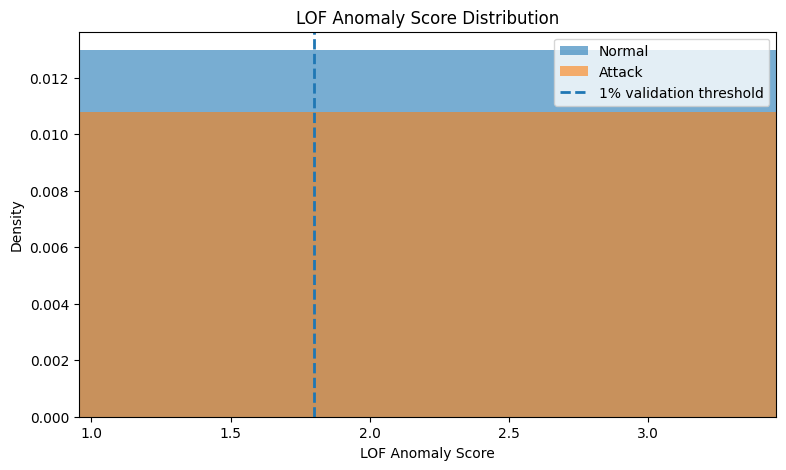

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/lof_scores.png


In [15]:
# PLOT NORMAL VS ATTACK LOF SCORES

normal_scores = test_scores[y_test == 0]
attack_scores = test_scores[y_test == 1]

plt.figure(figsize=(9, 5))

plt.hist(
    normal_scores,
    bins=100,
    alpha=0.6,
    density=True,
    label="Normal"
)

plt.hist(
    attack_scores,
    bins=100,
    alpha=0.6,
    density=True,
    label="Attack"
)

plt.axvline(
    thresholds["1% budget"],
    linestyle="--",
    linewidth=2,
    label="1% validation threshold"
)

plt.xlabel("LOF Anomaly Score")
plt.ylabel("Density")
plt.title("LOF Anomaly Score Distribution")
plt.legend()

# Limit extreme tails so the graph remains readable
plt.xlim(
    np.percentile(test_scores, 0.1),
    np.percentile(test_scores, 99)
)

LOF_SCORE_PLOT = REPORT_DIR / "lof_scores.png"

plt.savefig(
    LOF_SCORE_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", LOF_SCORE_PLOT)

In [16]:
# CREATE DASHBOARD PREDICTIONS

threshold_005 = thresholds["0.5% budget"]
threshold_01 = thresholds["1% budget"]
threshold_03 = thresholds["3% budget"]

lof_pred_005 = (test_scores >= threshold_005).astype(int)
lof_pred_01 = (test_scores >= threshold_01).astype(int)
lof_pred_03 = (test_scores >= threshold_03).astype(int)

In [17]:
# CREATE DASHBOARD-READY DATAFRAME

lof_dashboard_results = pd.DataFrame({
    "record_id": range(1, len(test_scores) + 1),
    "actual_label": y_test,
    "actual_class": [
        "Attack" if y == 1 else "Normal"
        for y in y_test
    ],
    "lof_score": test_scores,
    "lof_prediction_0.5pct": lof_pred_005,
    "lof_prediction_1pct": lof_pred_01,
    "lof_prediction_3pct": lof_pred_03,
    "lof_status_0.5pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in lof_pred_005
    ],
    "lof_status_1pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in lof_pred_01
    ],
    "lof_status_3pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in lof_pred_03
    ]
})
# Use 1% budget as the default dashboard operating point
lof_dashboard_results["default_threshold"] = threshold_01
lof_dashboard_results["default_prediction"] = lof_pred_01

lof_dashboard_results["default_status"] = [
    "Anomaly" if p == 1 else "Normal"
    for p in lof_pred_01
]

lof_dashboard_results["correct_prediction"] = (
    lof_dashboard_results["default_prediction"]
    == lof_dashboard_results["actual_label"]
)

In [18]:
# SAVE DASHBOARD CSV

LOF_DASHBOARD_FILE = REPORT_DIR / "lof_dashboard_results.csv"

lof_dashboard_results.to_csv(
    LOF_DASHBOARD_FILE,
    index=False
)

print("LOF dashboard results saved:")
print(LOF_DASHBOARD_FILE)
print("Shape:", lof_dashboard_results.shape)

display(lof_dashboard_results.head(10))


LOF dashboard results saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/lof_dashboard_results.csv
Shape: (82332, 14)


,record_id,actual_label,actual_class,lof_score,lof_prediction_0.5pct,lof_prediction_1pct,lof_prediction_3pct,lof_status_0.5pct,lof_status_1pct,lof_status_3pct,default_threshold,default_prediction,default_status,correct_prediction
0,1,0,Normal,1.315287,0,0,0,Normal,Normal,Normal,1.800995,0,Normal,True
1,2,0,Normal,1.150617,0,0,0,Normal,Normal,Normal,1.800995,0,Normal,True
2,3,0,Normal,0.964865,0,0,0,Normal,Normal,Normal,1.800995,0,Normal,True
3,4,0,Normal,0.979191,0,0,0,Normal,Normal,Normal,1.800995,0,Normal,True
4,5,0,Normal,1.029301,0,0,0,Normal,Normal,Normal,1.800995,0,Normal,True
5,6,0,Normal,1.022005,0,0,0,Normal,Normal,Normal,1.800995,0,Normal,True
6,7,0,Normal,1.039107,0,0,0,Normal,Normal,Normal,1.800995,0,Normal,True
7,8,0,Normal,1.096182,0,0,0,Normal,Normal,Normal,1.800995,0,Normal,True
8,9,0,Normal,1.004023,0,0,0,Normal,Normal,Normal,1.800995,0,Normal,True
9,10,0,Normal,1.004023,0,0,0,Normal,Normal,Normal,1.800995,0,Normal,True


In [19]:
# SAVE LOF MODEL

LOF_MODEL_FILE = MODEL_DIR / "lof_baseline.joblib"

joblib.dump(lof_model, LOF_MODEL_FILE)

print("Saved LOF model:")
print(LOF_MODEL_FILE)

Saved LOF model:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/models/lof_baseline.joblib


In [20]:
# SAVE LOF CONFIGURATION

LOF_CONFIG_FILE = CONFIG_DIR / "lof_baseline.json"

lof_information = {
    "model": "Local Outlier Factor",
    "model_type": "LOF baseline",
    "purpose": "Unsupervised network anomaly detection",
    "training_data": "train_normal.npz",
    "validation_data": "val_normal.npz",
    "test_data": "test_full.npz",
    "training_strategy": "Normal-only training",
    "input_features": int(X_train.shape[1]),
    "n_neighbors": 20,
    "metric": "minkowski",
    "p": 2,
    "contamination": "auto",
    "novelty": True,
    "score_direction": "Higher score means more anomalous",
    "score_definition": "negative of sklearn LOF score_samples",
    "random_seed": SEED,
    "roc_auc": float(lof_roc_auc),
    "pr_auc": float(lof_pr_auc),
    "thresholds": {
        label: float(value)
        for label, value in thresholds.items()
    }
}

with open(LOF_CONFIG_FILE, "w") as f:
    json.dump(lof_information, f, indent=4)

print("Saved configuration:")
print(LOF_CONFIG_FILE)

Saved configuration:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/lof_baseline.json


In [21]:
# VERIFY OUTPUT FILES

print("\nLOF implementation completed.")

print("\nFiles created:")
print("1.", LOF_MODEL_FILE.name)
print("2.", LOF_CONFIG_FILE.name)
print("3.", LOF_BUDGET_FILE.name)
print("4.", LOF_DASHBOARD_FILE.name)
print("5.", LOF_SCORE_PLOT.name)


LOF implementation completed.

Files created:
1. lof_baseline.joblib
2. lof_baseline.json
3. lof_budget_results.csv
4. lof_dashboard_results.csv
5. lof_scores.png


In [22]:
# CREATE LOF ZIP PACKAGE

import zipfile
from google.colab import files

LOF_ZIP_FILE = "/content/LOF_Results.zip"

files_to_zip = [
    LOF_MODEL_FILE,
    LOF_CONFIG_FILE,
    LOF_BUDGET_FILE,
    LOF_DASHBOARD_FILE,
    LOF_SCORE_PLOT
]

with zipfile.ZipFile(LOF_ZIP_FILE, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in files_to_zip:
        if file_path.exists():
            zipf.write(file_path, arcname=file_path.name)
            print("Added:", file_path.name)
        else:
            print("Missing:", file_path)

print("\nLOF package created successfully:")
print(LOF_ZIP_FILE)

files.download(LOF_ZIP_FILE)

Added: lof_baseline.joblib
Added: lof_baseline.json
Added: lof_budget_results.csv
Added: lof_dashboard_results.csv
Added: lof_scores.png

LOF package created successfully:
/content/LOF_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>